# Carregamento do conjunto de dados iris

In [1]:
#Carregar os dados
from sklearn import datasets

iris = datasets.load_iris()

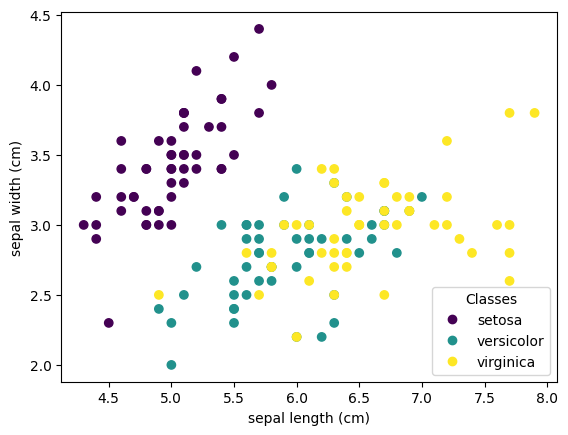

In [2]:
# plotar os dados
import matplotlib.pyplot as plt

_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

In [6]:

import pandas as pd

# Carregar os dados corretamente
iris = datasets.load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = df['target'].map(dict(enumerate(iris.target_names)))

# Tipagem das colunas
tipagem = df.dtypes.reset_index()
tipagem.columns = ['Coluna', 'Tipo']

# Valores ausentes
missing = df.isnull().sum().reset_index()
missing.columns = ['Coluna', 'Valores Faltantes']

# Estatísticas por espécie
mean = df.groupby('target_name').mean().add_suffix(' (média)')
median = df.groupby('target_name').median().add_suffix(' (mediana)')
q1 = df.groupby('target_name').quantile(0.25).add_suffix(' (Q1)')
q3 = df.groupby('target_name').quantile(0.75).add_suffix(' (Q3)')

# Unir tudo
summary = pd.concat([mean, median, q1, q3], axis=1).round(2)

# Juntar tipagem com valores faltantes
tipagem_missing = pd.merge(tipagem, missing, on='Coluna')

# Exibir
print(tipagem_missing)
summary

              Coluna     Tipo  Valores Faltantes
0  sepal length (cm)  float64                  0
1   sepal width (cm)  float64                  0
2  petal length (cm)  float64                  0
3   petal width (cm)  float64                  0
4             target    int64                  0
5        target_name   object                  0


,sepal length (cm) (média),sepal width (cm) (média),petal length (cm) (média),petal width (cm) (média),target (média),sepal length (cm) (mediana),sepal width (cm) (mediana),petal length (cm) (mediana),petal width (cm) (mediana),target (mediana),sepal length (cm) (Q1),sepal width (cm) (Q1),petal length (cm) (Q1),petal width (cm) (Q1),target (Q1),sepal length (cm) (Q3),sepal width (cm) (Q3),petal length (cm) (Q3),petal width (cm) (Q3),target (Q3)
target_name,,,,,,,,,,,,,,,,,,,,
setosa,5.01,3.43,1.46,0.25,0.0,5.0,3.4,1.50,0.2,0.0,4.80,3.20,1.4,0.2,0.0,5.2,3.68,1.58,0.3,0.0
versicolor,5.94,2.77,4.26,1.33,1.0,5.9,2.8,4.35,1.3,1.0,5.60,2.52,4.0,1.2,1.0,6.3,3.00,4.60,1.5,1.0
virginica,6.59,2.97,5.55,2.03,2.0,6.5,3.0,5.55,2.0,2.0,6.22,2.80,5.1,1.8,2.0,6.9,3.18,5.88,2.3,2.0


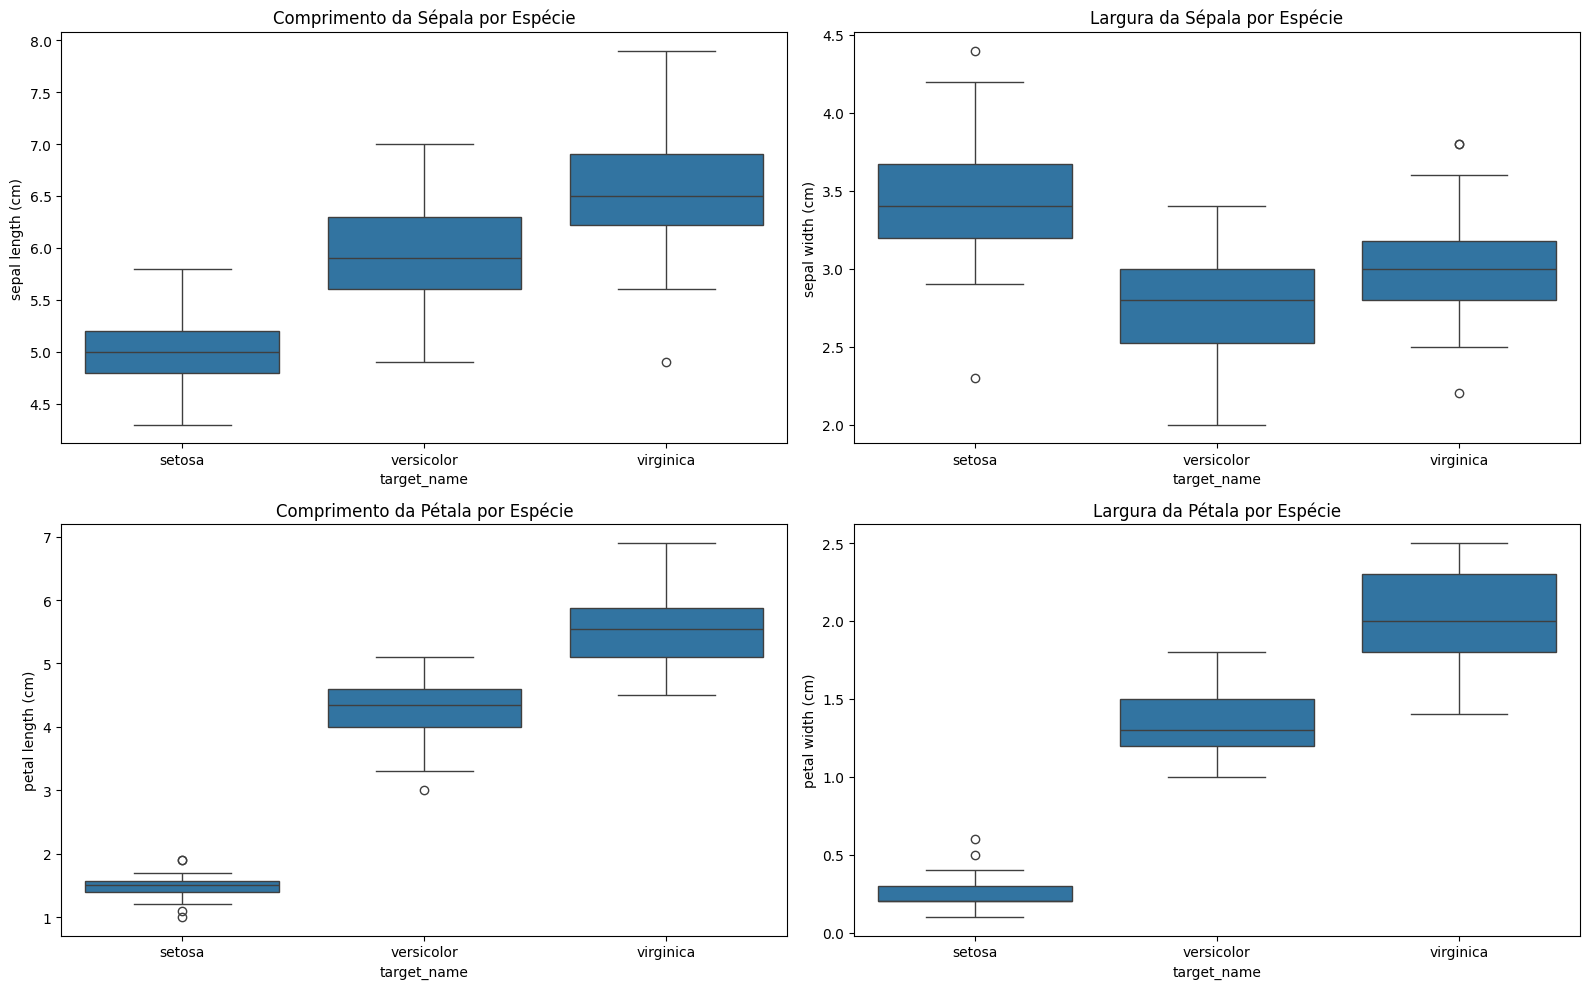

In [8]:
# Reimportar bibliotecas (caso kernel tenha reiniciado)
import seaborn as sns
import matplotlib.pyplot as plt

# Gráficos de boxplot por espécie
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.boxplot(data=df, x='target_name', y='sepal length (cm)', ax=axes[0, 0])
axes[0, 0].set_title('Comprimento da Sépala por Espécie')

sns.boxplot(data=df, x='target_name', y='sepal width (cm)', ax=axes[0, 1])
axes[0, 1].set_title('Largura da Sépala por Espécie')

sns.boxplot(data=df, x='target_name', y='petal length (cm)', ax=axes[1, 0])
axes[1, 0].set_title('Comprimento da Pétala por Espécie')

sns.boxplot(data=df, x='target_name', y='petal width (cm)', ax=axes[1, 1])
axes[1, 1].set_title('Largura da Pétala por Espécie')

plt.tight_layout()
plt.show()



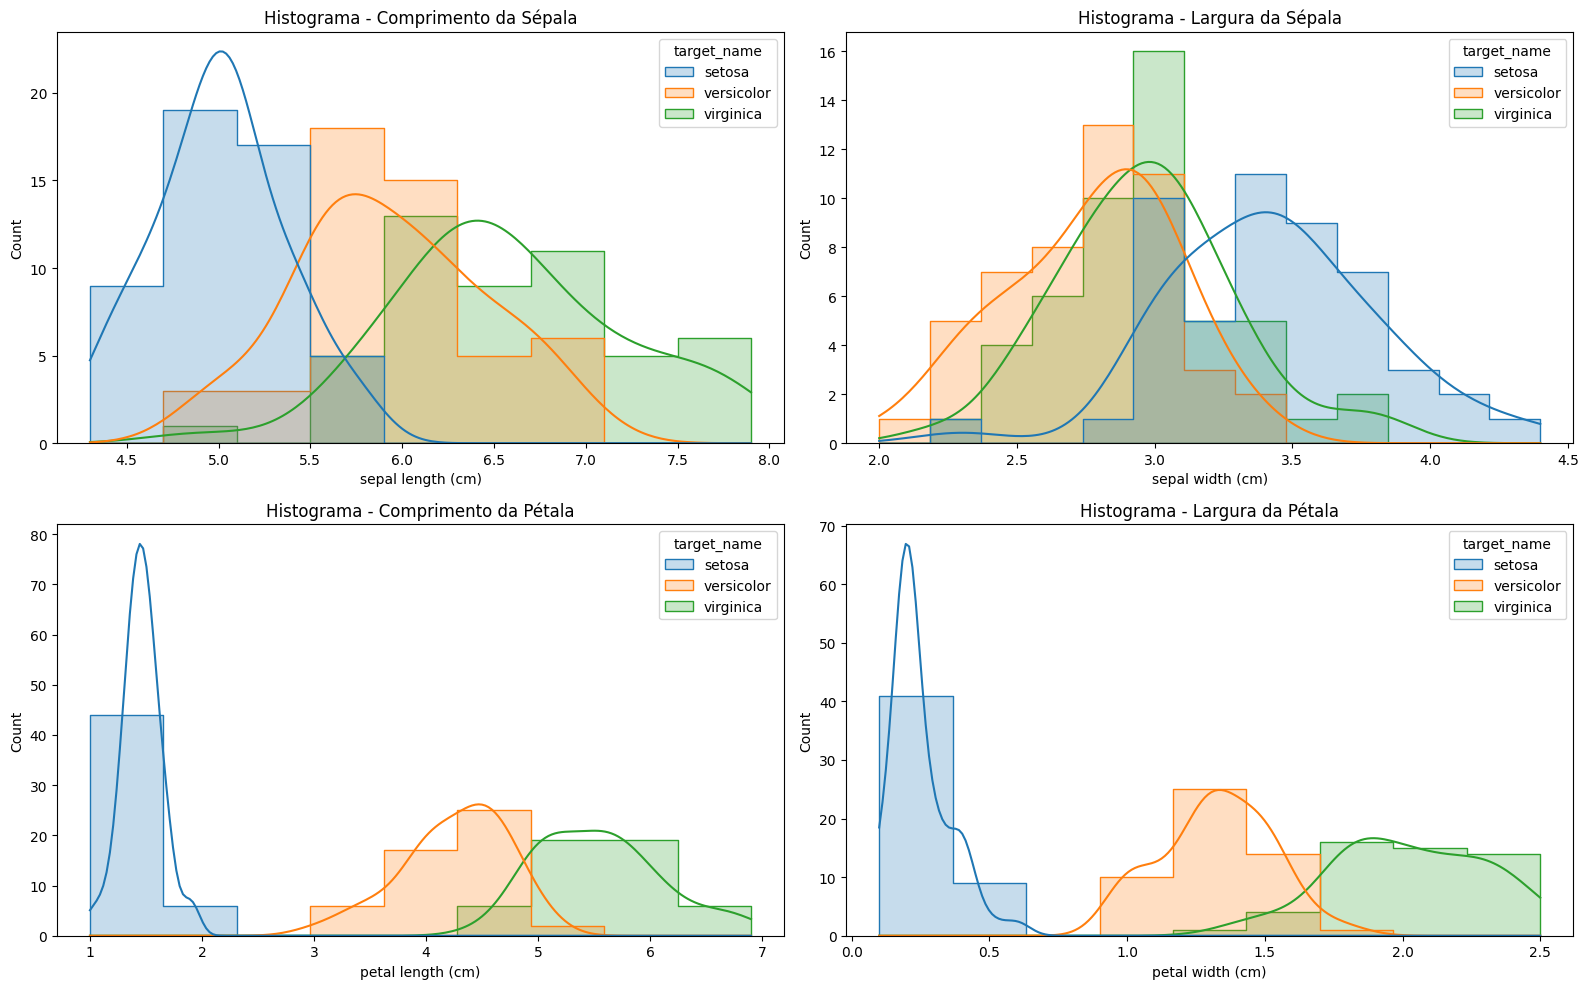

In [9]:
# Gerar histogramas com densidade para cada atributo por espécie
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(data=df, x='sepal length (cm)', hue='target_name', kde=True, ax=axes[0, 0], element='step')
axes[0, 0].set_title('Histograma - Comprimento da Sépala')

sns.histplot(data=df, x='sepal width (cm)', hue='target_name', kde=True, ax=axes[0, 1], element='step')
axes[0, 1].set_title('Histograma - Largura da Sépala')

sns.histplot(data=df, x='petal length (cm)', hue='target_name', kde=True, ax=axes[1, 0], element='step')
axes[1, 0].set_title('Histograma - Comprimento da Pétala')

sns.histplot(data=df, x='petal width (cm)', hue='target_name', kde=True, ax=axes[1, 1], element='step')
axes[1, 1].set_title('Histograma - Largura da Pétala')

plt.tight_layout()
plt.show()


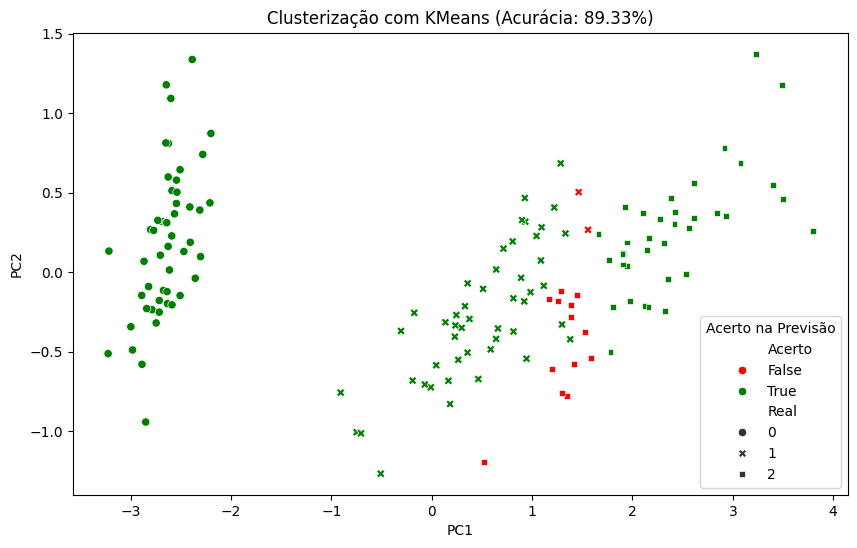

In [11]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import numpy as np

# Aplicar PCA para reduzir a dimensionalidade para visualização (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df[iris.feature_names])

# Aplicar KMeans com 3 clusters (esperado para Iris)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df[iris.feature_names])

# Mapear rótulos reais para clusters (manual, pois KMeans não conhece os rótulos)
# Atribuímos o rótulo mais comum em cada cluster
df_cluster = pd.DataFrame({'true_label': df['target'], 'cluster': clusters})
mapping = df_cluster.groupby('cluster')['true_label'].agg(lambda x: x.mode()[0])
predicted_labels = df_cluster['cluster'].map(mapping)

# Acurácia dos clusters
acc = accuracy_score(df['target'], predicted_labels)

# Adicionar PCA para visualização
df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_plot['Predito'] = predicted_labels
df_plot['Real'] = df['target']
df_plot['Acerto'] = df_plot['Predito'] == df_plot['Real']

# Plotar
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Acerto', style='Real', palette={True: 'green', False: 'red'})
plt.title(f'Clusterização com KMeans (Acurácia: {acc:.2%})')
plt.legend(title='Acerto na Previsão')
plt.show()


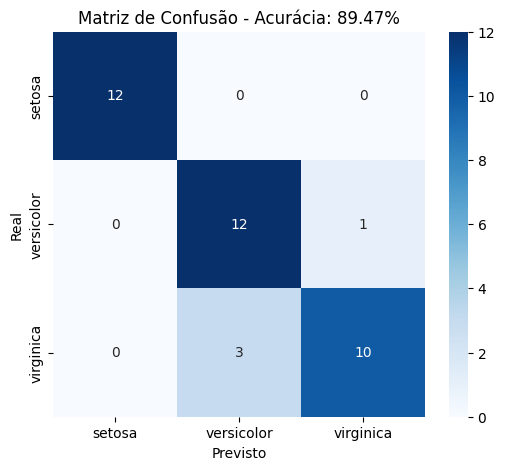

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Refazer o split com estratificação e proporção mais realista
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Treinar novamente o modelo
clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# Predição
y_pred = clf.predict(X_test)

# Avaliação
acc_clf_improved = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Visualizar matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title(f'Matriz de Confusão - Acurácia: {acc_clf_improved:.2%}')
plt.show()


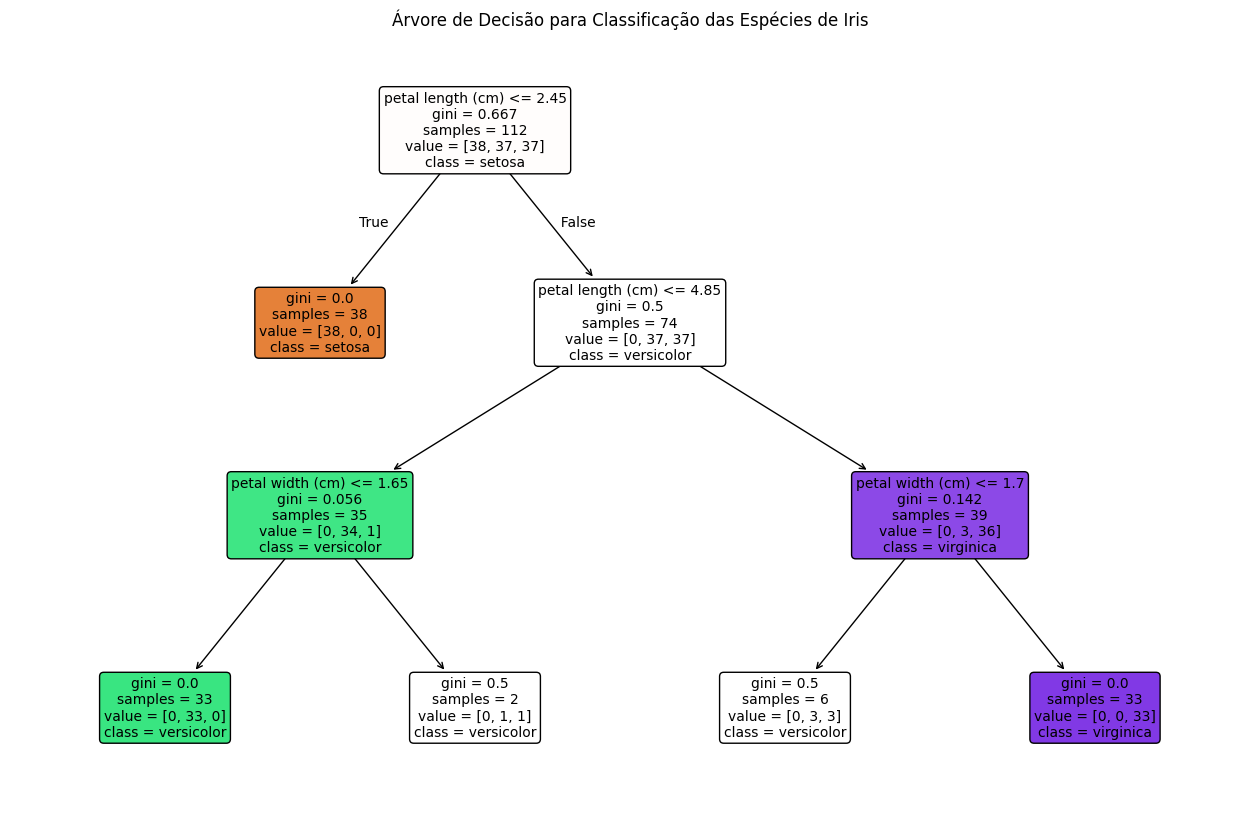

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Treinar uma árvore de decisão com profundidade controlada
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)

# Visualizar a árvore
plt.figure(figsize=(16, 10))
plot_tree(
    tree_clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árvore de Decisão para Classificação das Espécies de Iris')
plt.show()
